<a href="https://colab.research.google.com/github/ZukhrufianAbdullah/PCVK_Ganjil_2026/blob/main/Week-01/Pertemuan_2b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive

# Accessing My Google Drive
drive.mount('/content/drive')

import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import numpy as np
import cv2 as cv

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Menampilkan Gambar

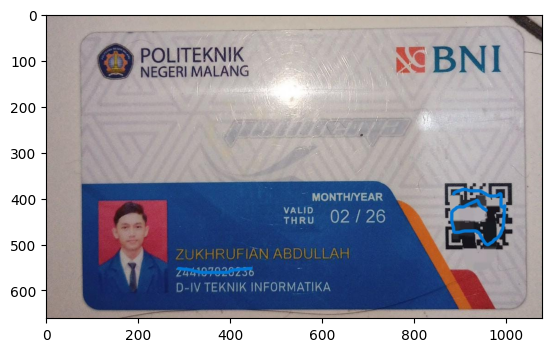

In [5]:
img = cv2.imread("/content/drive/MyDrive/PCVK/Gambar/ktm.jpeg")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) #Konfersi BGR ke RGB
plt.show()

Menampilkan citra Grayscale:

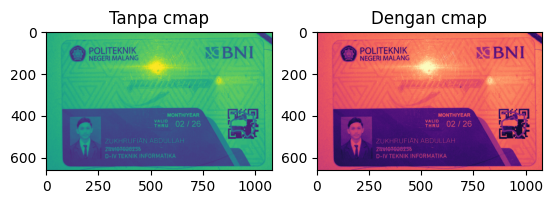

In [6]:
img_gray = cv2.imread("/content/drive/MyDrive/PCVK/Gambar/ktm.jpeg", cv2.IMREAD_GRAYSCALE)

# Tanpa cmap
plt.subplot(1,2,1)
plt.imshow(img_gray)
plt.title('Tanpa cmap')

# Dengan cmap
plt.subplot(1,2,2)
plt.imshow(img_gray, cmap='magma')
plt.title('Dengan cmap')

plt.show()


Melakukan resizing

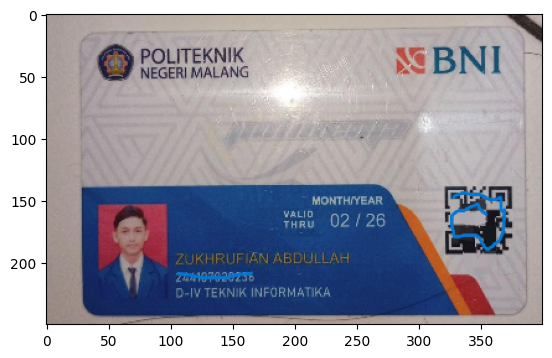

In [7]:
img = cv2.imread("/content/drive/MyDrive/PCVK/Gambar/ktm.jpeg")
imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #Konversi BGR ke RGB
imgRGBsmall = cv2.resize(imgRGB,(400,250))
plt.imshow(imgRGBsmall)

Melakukan Flipping

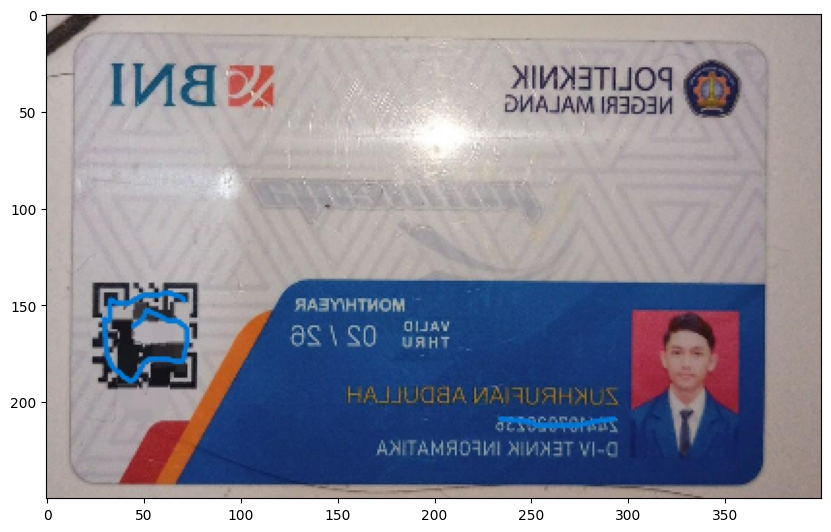

In [8]:
imgBalik = cv2.flip(imgRGBsmall, 1)

#tampilkan ukuran canvas yang lebih besar
fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot(111)
ax.imshow(imgBalik)

Membuat bentuk Geometri 2D dari OpenCV. Diawali dengan pembuatan black image dengan tipe data int16.

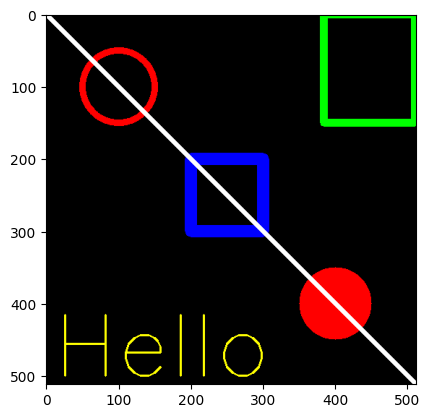

In [9]:
black_img = np.zeros(shape=(512,512,3),dtype=np.int16)
plt.imshow(black_img)

#perhatikan kordinat titik2 pt1 dan pt2
cv.rectangle(black_img, pt1=(384,0), pt2=(510,150), color=(0,255,0), thickness=10)
plt.imshow(black_img)

cv.rectangle(black_img, pt1=(200,200), pt2=(300,300), color=(0,0,255), thickness=15)
plt.imshow(black_img)

cv.circle(black_img, center=(100,100), radius=50, color=(255,0,0), thickness=8)
plt.imshow(black_img)

cv.circle(black_img, center=(400,400), radius=50, color=(255,0,0), thickness=-1)
plt.imshow(black_img)

cv.line(black_img, pt1=(0,0), pt2=(512,512), color=(255,255,255), thickness=5)
plt.imshow(black_img)

font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img, text='Hello', org=(10,500), fontFace=font, fontScale=4, color=(255,255,0), thickness=2, lineType=cv.LINE_AA)
plt.imshow(black_img)

Pembuatan black image kembali dilakukan dengan tipe data int32

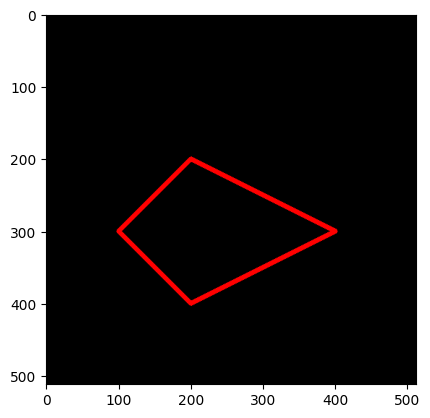

In [10]:
black_img2 = np.zeros(shape=(512,512,3),dtype=np.int32)
plt.imshow(black_img2)

vertices = np.array([[100, 300],
                     [200, 200],
                     [400, 300],
                     [200, 400]], dtype=np.int32)
pts = vertices.reshape((-1, 1, 2)) # nilai 2 untuk menunjukkan bahwa tiap titik dibuat 3 channel yang mewakili R, G, dan B
pts

cv.polylines(black_img2, [pts], isClosed=True, color=(255, 0, 0), thickness=5)
plt.imshow(black_img2)


# PERTANYAAN PRAKTIKUM D3

1. Apakah perbedaan gambar yang ditampilkan tanpa dan dengan matplotlib? Tanpa matplotlib (menggunakan cv2_imshow() dari Google Colab), gambar ditampilkan langsung dalam format BGR (Blue-Green-Red) sesuai dengan format default OpenCV. Tampilan ini lebih cepat dan praktis untuk preview cepat karena langsung muncul di output cell.

    Dengan matplotlib (menggunakan plt.imshow()), gambar ditampilkan dalam format RGB (Red-Green-Blue) sehingga warnanya lebih natural seperti yang kita lihat sehari-hari. Keunggulan matplotlib adalah kita bisa mengatur ukuran gambar (figsize), menambahkan judul (title), mengubah colormap (cmap), menampilkan beberapa gambar sekaligus dalam satu grid (subplot), serta menyimpan gambar dengan kualitas tinggi. Namun, perlu diingat bahwa jika gambar dari OpenCV (format BGR) langsung ditampilkan dengan matplotlib tanpa konversi, warnanya akan terlihat aneh (merah dan biru tertukar), sehingga perlu dikonversi terlebih dahulu menggunakan cv2.cvtColor(img, cv2.COLOR_BGR2RGB).

2. Apakah perbedaan dan pengaruhnya pembuatan black image antara tipe data int16 dan int32? Tipe data int16 memiliki rentang nilai dari -32.768 hingga 32.767 dengan ukuran 2 byte per elemen, cukup untuk menyimpan nilai pixel 0-255 pada citra digital. Penggunaan int16 lebih efisien dalam penggunaan memori karena ukurannya lebih kecil.

    Tipe data int32 memiliki rentang nilai dari -2.147.483.648 hingga 2.147.483.647 dengan ukuran 4 byte per elemen. Penggunaan int32 memakan memori dua kali lebih besar dibandingkan int16.

3. Apakah kegunaan “google.colab.patches import cv2_imshow” pada potongan kode berikut
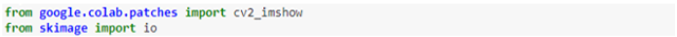
cv2_imshow adalah fungsi alternatif dari OpenCV yang khusus digunakan di lingkungan Google Colab. Fungsi ini berfungsi untuk menampilkan gambar langsung di output notebook dengan format yang kompatibel. Berbeda dengan cv2.imshow() yang membutuhkan jendela GUI terpisah dan sering bermasalah di Colab, cv2_imshow() dapat menampilkan gambar langsung di dalam cell output tanpa perlu membuat jendela baru. Fungsi ini sangat berguna karena Google Colab berjalan di browser dan tidak mendukung tampilan GUI seperti pada desktop, sehingga cv2_imshow() menjadi solusi praktis untuk menampilkan hasil pemrosesan gambar secara instan di notebook.
4. Apakah kegunaan “skimage import io” pada potongan kode soal nomor 3? skimage.io adalah submodul dari library scikit-image yang berfungsi untuk melakukan operasi input/output (I/O) pada gambar. Fungsi yang paling sering digunakan adalah io.imread() untuk membaca gambar dari berbagai sumber seperti file lokal, URL, atau path direktori. Keunggulan skimage.io.imread() dibandingkan cv2.imread() adalah kemampuannya membaca gambar dari berbagai format dan sumber (termasuk dari URL internet) secara langsung, serta secara otomatis mengembalikan gambar dalam format RGB (bukan BGR seperti OpenCV). Hal ini memudahkan kita ketika ingin mengambil gambar dari internet tanpa perlu mendownload terlebih dahulu, seperti yang dilakukan pada praktikum D2 saat membaca gambar dari URL situs NCSU dan placekitten.

# TUGAS PRAKTIKUM D3

1. Analisis figsize Secara teknis, figsize pada matplotlib hanya mengubah ukuran tampilan (display) pada notebook, bukan mengubah jumlah pixel asli dalam array citra (ndarray).

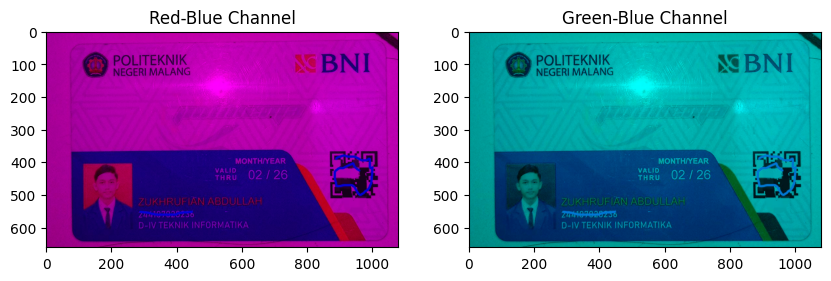

In [11]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img_ori = cv2.imread("/content/drive/MyDrive/PCVK/Gambar/ktm.jpeg")
img_rgb = cv2.cvtColor(img_ori, cv2.COLOR_BGR2RGB)

# 2. Tampilkan image dalam channel Red-Blue dan Green-Blue saja
img_rb = img_rgb.copy()
img_rb[:,:,1] = 0

img_gb = img_rgb.copy()
img_gb[:,:,0] = 0

plt.figure(figsize=(10, 5))
plt.subplot(1,2,1); plt.imshow(img_rb); plt.title('Red-Blue Channel')
plt.subplot(1,2,2); plt.imshow(img_gb); plt.title('Green-Blue Channel')
plt.show()

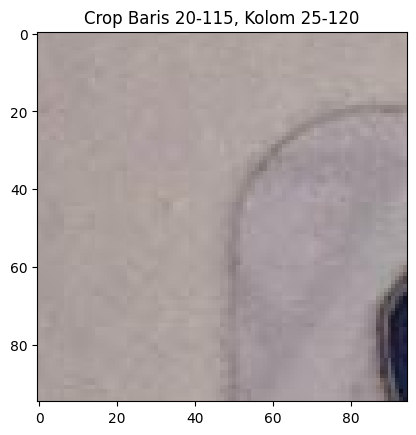

In [12]:
# 3. Tampilkan image baris ke 20-115, kolom 25-120
img_crop1 = img_rgb[20:115, 25:120]
plt.imshow(img_crop1)
plt.title('Crop Baris 20-115, Kolom 25-120')
plt.show()

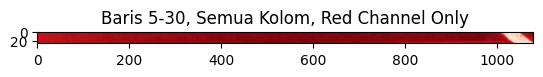

In [13]:
# 4. Tampilkan image baris ke 5-30, semua kolom, channel Red saja
img_red_strip = img_rgb[5:30, :, 0]
plt.imshow(img_red_strip, cmap='Reds')
plt.title('Baris 5-30, Semua Kolom, Red Channel Only')
plt.show()

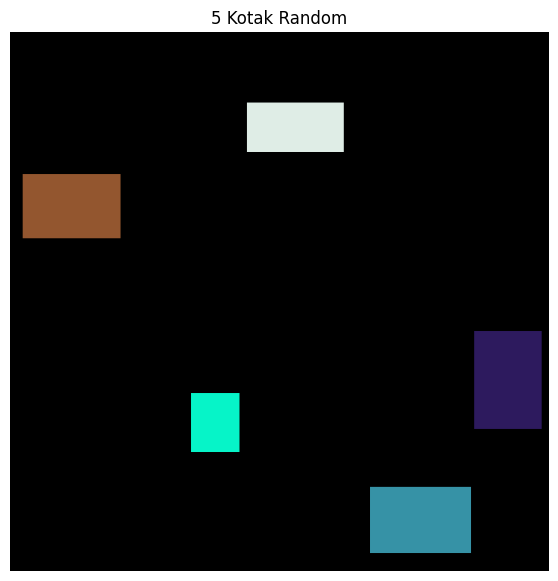

In [14]:
canvas = np.zeros((512, 512, 3), dtype=np.uint8)

boxes = []

jumlah_kotak = 5

jarak_minimum = 30

for _ in range(jumlah_kotak):

    while True:
        lebar_kotak = np.random.randint(40, 100)
        tinggi_kotak = np.random.randint(40, 100)

        x1 = np.random.randint(0, 512 - lebar_kotak)
        y1 = np.random.randint(0, 512 - tinggi_kotak)

        x2 = x1 + lebar_kotak
        y2 = y1 + tinggi_kotak

        terlalu_dekat = False

        for (bx1, by1, bx2, by2) in boxes:

            if not (
                x1 > bx2 + jarak_minimum or
                x2 < bx1 - jarak_minimum or
                y1 > by2 + jarak_minimum or
                y2 < by1 - jarak_minimum
            ):
                terlalu_dekat = True
                break

        if not terlalu_dekat:
            break

    color = (
        np.random.randint(0, 256),
        np.random.randint(0, 256),
        np.random.randint(0, 256)
    )

    cv2.rectangle(
        canvas,
        (x1, y1),
        (x2, y2),
        color,
        -1
    )

    boxes.append((x1, y1, x2, y2))

plt.figure(figsize=(7, 7))
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.title('5 Kotak Random')
plt.axis('off')
plt.show()


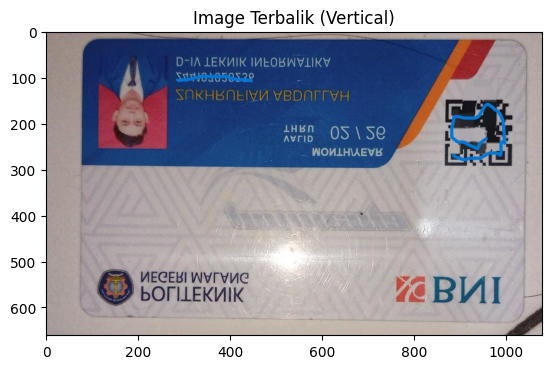

In [15]:
# 6. Tampilkan image dengan posisi terbalik (Vertical Flip)
img_flip = cv2.flip(img_rgb, 0)
plt.imshow(img_flip)
plt.title('Image Terbalik (Vertical)')
plt.show()

In [16]:
# 7. Rectangle & Circle pada wajah (Contoh menggunakan koordinat manual)
import os
path_folder = '/content/drive/MyDrive/'
if os.path.exists(path_folder):
    files = os.listdir(path_folder)
    if 'fian.jpg' in files:
        print('File fian.jpg ditemukan!')
    else:
        print('Daftar file di Drive:', files)
else:
    print('Drive belum terpasang.')

File fian.jpg ditemukan!


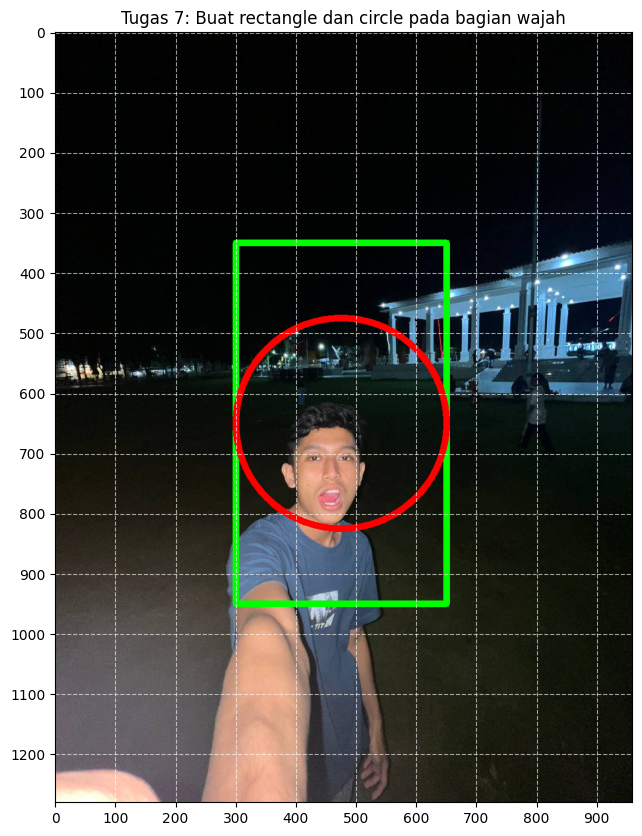

In [17]:
import cv2
import matplotlib.pyplot as plt

x = 300
y = 350
w = 350
h = 600

path_selfie = "/content/drive/MyDrive/fian.jpg"
img_selfie_bgr = cv2.imread(path_selfie)

if img_selfie_bgr is not None:
    img_selfie_rgb = cv2.cvtColor(img_selfie_bgr, cv2.COLOR_BGR2RGB)
    img_tugas7 = img_selfie_rgb.copy()
    height, width, _ = img_tugas7.shape

    cv2.rectangle(img_tugas7, (x, y), (x + w, y + h), (0, 255, 0), 10)

    center_x = x + (w // 2)
    center_y = y + (h // 2)
    radius = min(w, h) // 2
    cv2.circle(img_tugas7, (center_x, center_y), radius, (255, 0, 0), 10)

    plt.figure(figsize=(10, 10))
    plt.imshow(img_tugas7)
    plt.title("Tugas 7: Buat rectangle dan circle pada bagian wajah")

    plt.grid(True, color='white', linestyle='--', alpha=0.6)
    plt.xticks(range(0, width, 100))
    plt.yticks(range(0, height, 100))
    plt.axis("on")
    plt.show()
else:
    print(f"File tidak ditemukan di: {path_selfie}")

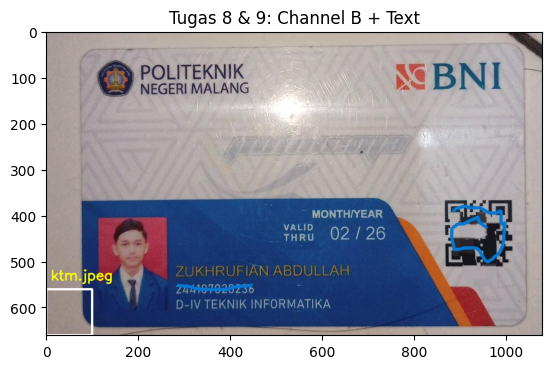

In [18]:
# 8 & 9. Rectangle pada sudut bawah kiri channel B & Nama File
h, w, c = img_rgb.shape
img_blue = img_rgb.copy()
cv2.rectangle(img_blue, (0, h-100), (100, h), (255, 255, 255), 3)

font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(img_blue, 'ktm.jpeg', (10, h-120), font, 1, (255, 255, 0), 2, cv2.LINE_AA)

plt.imshow(img_blue)
plt.title('Tugas 8 & 9: Channel B + Text')
plt.show()

# TUGAS PRAKTIKUM KELOMPOK

In [19]:
# Akses file image lokal (KTM) dan tampilkan menggunakan OpenCV dan Matplotlib
# Kelompok 3 bagian tulisan POLITEKNIK NEGERI MALANG, BNI dan Prodi


**Menutupi Bagian Teks pada KTM (Tugas Kelompok 3)**

Berikut adalah kode untuk menutupi bagian 'POLITEKNIK NEGERI MALANG', 'BNI', dan 'D-IV TEKNIK INFORMATIKA' pada gambar KTM.

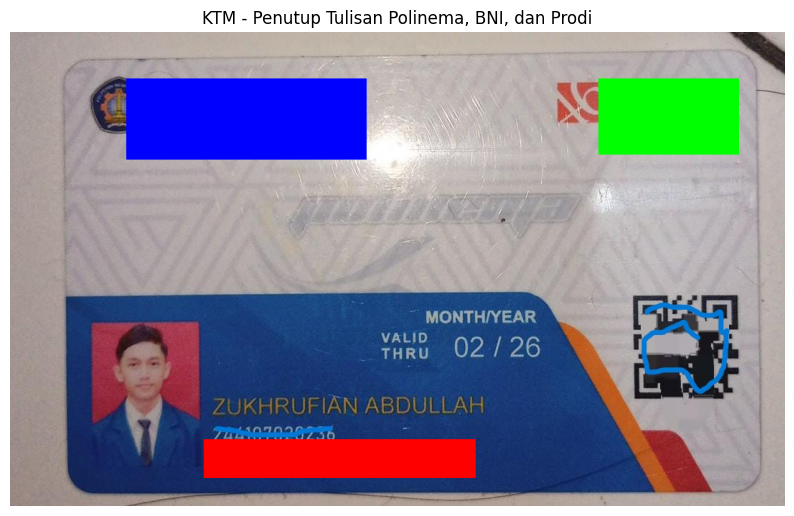

In [20]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img_modified = img_rgb.copy()

h, w, _ = img_modified.shape

# ==========================================
# 1. POLITEKNIK NEGERI MALANG - BIRU
# ==========================================
x1_poltek = int(w * 0.15)
y1_poltek = int(h * 0.10)

x2_poltek = int(w * 0.46)
y2_poltek = int(h * 0.27)

color_poltek = (0, 0, 255)

cv2.rectangle(
    img_modified,
    (x1_poltek, y1_poltek),
    (x2_poltek, y2_poltek),
    color_poltek,
    -1
)


# ==========================================
# 2. BNI - HIJAU
# ==========================================
x1_bni = int(w * 0.76)
y1_bni = int(h * 0.10)

x2_bni = int(w * 0.94)
y2_bni = int(h * 0.26)

color_bni = (0, 255, 0)

cv2.rectangle(
    img_modified,
    (x1_bni, y1_bni),
    (x2_bni, y2_bni),
    color_bni,
    -1
)


# ==========================================
# 3. D-IV TEKNIK INFORMATIKA - MERAH
# ==========================================
x1_prodi = int(w * 0.25)
y1_prodi = int(h * 0.86)

x2_prodi = int(w * 0.60)
y2_prodi = int(h * 0.94)

color_prodi = (255, 0, 0)

cv2.rectangle(
    img_modified,
    (x1_prodi, y1_prodi),
    (x2_prodi, y2_prodi),
    color_prodi,
    -1
)

plt.figure(figsize=(10, 8))
plt.imshow(img_modified)
plt.title('KTM - Penutup Tulisan Polinema, BNI, dan Prodi')
plt.axis('off')
plt.show()
